<!-- # Computational Astrophysics -->
## Lecture 7: Numerical Differentiation and Integration

**Course:** Computational Astrophysics  
**Program:** M.Sc. Physics (Astronomy & Astrophysics)

In this lecture, we introduce numerical differentiation and numerical integration,
two fundamental tools required when analytical expressions are unavailable or
when working with discrete observational data.


### Learning Objectives

After completing this lecture, students will be able to:

1. Understand why numerical differentiation and integration are required
2. Implement finite difference schemes for derivatives
3. Apply common numerical integration techniques
4. Estimate physical quantities from astrophysical data using numerical methods


### Why Do We Need Numerical Methods?

In astrophysics, we frequently encounter:

- Discrete observational data
- Noisy measurements
- Functions with no closed-form derivatives or integrals

Examples:
- Velocity estimation from positional data
- Acceleration from velocity curves
- Mass estimation from density profiles
- Luminosity calculation from flux measurements

Numerical differentiation and integration allow us to extract meaningful physical
quantities from such data.


### Numerical Differentiation

The derivative of a function is defined as:

$$ \frac{df}{dx} = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h} $$

In numerical work, the limit cannot be taken exactly.
Instead, we approximate derivatives using finite differences.


#### Finite Difference Approximations

1. **Forward Difference**
$$ f'(x_i) \approx \frac{f(x_{i+1}) - f(x_i)}{h}$$

2. **Backward Difference**
$$
f'(x_i) \approx \frac{f(x_i) - f(x_{i-1})}{h} $$

3. **Central Difference**
$$ f'(x_i) \approx \frac{f(x_{i+1}) - f(x_{i-1})}{2h} $$

Central difference is generally more accurate.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


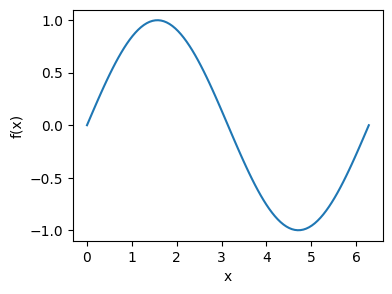

In [ ]:
def f(x):
    return (np.sin(x))

x = np.linspace(0, 2*np.pi, 100)
y = f(x)

fig = plt.figure(figsize=(4,3))

plt.plot(x, y)
plt.xlabel('x')
plt.ylabel('f(x)')

plt.show()


In [ ]:
y_temp = np.array([1, 25, 3, 4, 5])

print(np.diff(y_temp))

[ 24 -22   1   1]


In [ ]:
def forward_difference(y, x):
    return np.diff(y) / np.diff(x)

def central_difference(y, x):
    return (y[2:] - y[:-2]) / (x[2:] - x[:-2])

true_derivative = np.cos(x)

fd = forward_difference(y, x)
cd = central_difference(y, x)


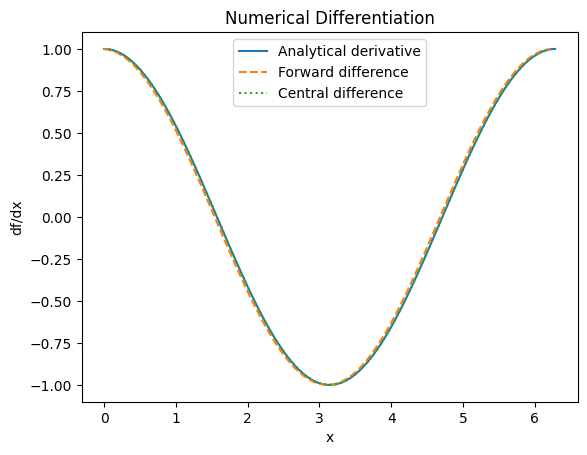

In [ ]:
plt.figure()
plt.plot(x, true_derivative, label="Analytical derivative")
plt.plot(x[:-1], fd, "--", label="Forward difference")
plt.plot(x[1:-1], cd, ":", label="Central difference")
plt.xlabel("x")
plt.ylabel("df/dx")
plt.legend()
plt.title("Numerical Differentiation")
plt.show()


### Important Observation

- Differentiation amplifies noise
- Smaller step size does not always mean better results
- Numerical derivatives of observational data must be handled carefully


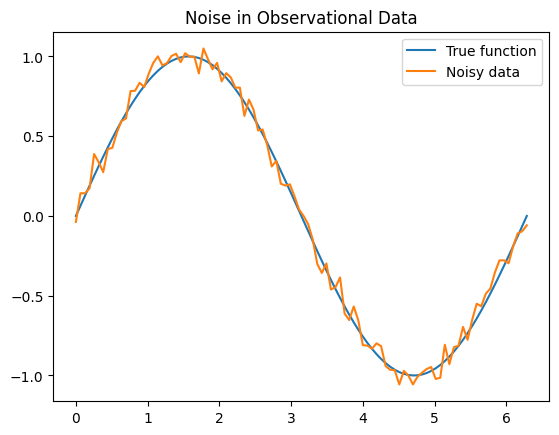

In [ ]:
noise = 0.05 * np.random.normal(size=len(y))
y_noisy = y + noise

cd_noisy = central_difference(y_noisy, x)

plt.figure()
plt.plot(x, y, label="True function")
plt.plot(x, y_noisy, label="Noisy data")
plt.legend()
plt.title("Noise in Observational Data")
plt.show()


### Numerical Integration

Integration is often more stable than differentiation.

The definite integral is defined as:

$$\int_a^b f(x) dx $$

When analytical integration is not possible, we use numerical methods.


#### Common Numerical Integration Methods

1. Trapezoidal Rule
2. Simpson's Rule

These methods approximate the area under a curve using simple geometric shapes.


# Numerical Integration Techniques
**Objective:** Understand how to approximate definite integrals using numerical methods when analytical solutions are difficult or impossible to find.

We will cover:
1. **The Midpoint Rule** (Rectangle approximation)
2. **The Trapezoidal Rule** (Linear approximation)
3. **Simpson's Rule** (Quadratic approximation)
4. **Error Analysis** (Convergence rates)
5. **SciPy Implementation** (The professional standard)

### The Problem
We want to evaluate the definite integral of a function $f(x)$ from $a$ to $b$:
$$I = \int_{a}^{b} f(x) \, dx$$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as spi

# Define our test function and analytical integral
def f(x):
    return np.sin(x)

def analytical_integral(x):
    return -np.cos(x)

# Integration limits
a, b = 0, np.pi
exact_solution = analytical_integral(b) - analytical_integral(a)

print(f"Exact Solution: {exact_solution}")

Exact Solution: 2.0


## 1. The Midpoint Rule
The Midpoint Rule approximates the area under the curve using rectangles. The height of each rectangle is determined by the function value at the *center* of the sub-interval.

**Formula:**
$$M_N = \sum_{i=1}^{N} f(\bar{x}_i) \Delta x$$
where $\Delta x = \frac{b-a}{N}$ and $\bar{x}_i$ is the midpoint of the interval.

In [ ]:
def midpoint_rule(f, a, b, N):
    dx = (b - a) / N
    # Generate midpoints: start at a + dx/2, end at b - dx/2
    x_mid = np.linspace(a + dx/2, b - dx/2, N)

    # Area = width * sum of heights
    return dx * np.sum(f(x_mid))

# Test with N=10 intervals
N = 10
approx = midpoint_rule(f, a, b, N)
print(f"Midpoint Rule (N={N}): {approx:.6f}")
print(f"Error: {abs(approx - exact_solution):.6f}")

Midpoint Rule (N=10): 2.008248
Error: 0.008248


## 2. The Trapezoidal Rule
Instead of rectangles, we use trapezoids to connect the points on the curve. This often provides a better approximation for sloping curves.

**Formula:**
$$T_N = \frac{\Delta x}{2} \left[ f(x_0) + 2\sum_{i=1}^{N-1} f(x_i) + f(x_N) \right]$$

In [ ]:
def trapezoidal_rule(f, a, b, N):
    h = (b - a) / N
    x = np.linspace(a, b, N+1)
    y = f(x)

    # Formula: h/2 * (first + 2*sum(intermediates) + last)
    return (h/2) * (y[0] + 2 * np.sum(y[1:-1]) + y[-1])

# Test
approx_trap = trapezoidal_rule(f, a, b, N)
print(f"Trapezoidal Rule (N={N}): {approx_trap:.6f}")
print(f"Error: {abs(approx_trap - exact_solution):.6f}")

Trapezoidal Rule (N=10): 1.983524
Error: 0.016476


In [ ]:
def trapezoidal_rule_array(y, x):
    return np.sum((y[1:] + y[:-1]) * (x[1:] - x[:-1]) / 2)

## 3. Simpson's Rule
Simpson's Rule fits a quadratic polynomial (parabola) through every three points. It is generally much more accurate than the previous methods for smooth functions. **Note:** $N$ must be even.

**Formula:**
$$S_N = \frac{\Delta x}{3} \left[ f(x_0) + 4 \sum_{i \text{ odd}} f(x_i) + 2 \sum_{i \text{ even}} f(x_i) + f(x_N) \right]$$

In [ ]:
def simpson_rule(y, x):
    if len(x) % 2 == 0:
        raise ValueError("Simpson's rule requires an odd number of points")
    h = x[1] - x[0]
    return (h/3) * (y[0] + y[-1]
                    + 4*np.sum(y[1:-1:2])
                    + 2*np.sum(y[2:-2:2]))


In [ ]:
def simpsons_rule(f, a, b, N):
    if N % 2 != 0:
        raise ValueError("N must be even for Simpson's Rule")

    h = (b - a) / N
    x = np.linspace(a, b, N+1)
    y = f(x)

    # Vectorized sum using slicing
    # y[1:-1:2] selects indices 1, 3, 5... (Odd in 0-indexing relative to inner points)
    # y[2:-2:2] selects indices 2, 4, 6... (Even)

    return (h/3) * (y[0] + 4*np.sum(y[1:-1:2]) + 2*np.sum(y[2:-1:2]) + y[-1])

# Test
approx_simp = simpsons_rule(f, a, b, N)
print(f"Simpson's Rule (N={N}): {approx_simp:.6f}")
print(f"Error: {abs(approx_simp - exact_solution):.6f}")

Simpson's Rule (N=10): 2.000110
Error: 0.000110


In [ ]:
trap_result = trapezoidal_rule_array(y, x)

x_s = np.linspace(0, 2*np.pi, 101)
y_s = f(x_s)
simp_result = simpson_rule(y_s, x_s)

print("Trapezoidal result:", trap_result)
print("Simpson result:", simp_result)
print("Exact value:", 2.0)

Trapezoidal result: -1.491862189340054e-16
Simpson result: 9.98430830811263e-18
Exact value: 2.0


## 4. Visualizing Convergence
How quickly does the error drop as we increase $N$?
* **Trapezoidal:** Error scales with $1/N^2$ ($O(h^2)$)
* **Simpson's:** Error scales with $1/N^4$ ($O(h^4)$) - *Much faster!*

In [ ]:
N_values = [10, 20, 40, 80, 160]
errors_trap = []
errors_simp = []

for n in N_values:
    e_trap = abs(trapezoidal_rule(f, a, b, n) - exact_solution)
    e_simp = abs(simpsons_rule(f, a, b, n) - exact_solution)
    errors_trap.append(e_trap)
    errors_simp.append(e_simp)

plt.figure(figsize=(10, 6))
plt.loglog(N_values, errors_trap, 'o-', label="Trapezoidal Error ($O(h^2)$)")
plt.loglog(N_values, errors_simp, 's-', label="Simpson's Error ($O(h^4)$)")
plt.xlabel('Number of Intervals (N)')
plt.ylabel('Absolute Error (log scale)')
plt.title('Convergence of Numerical Integration Methods')
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()

TypeError: trapezoidal_rule() takes 2 positional arguments but 4 were given

## 5. Using `scipy.integrate.quad`
In practice, you rarely write integration loops manually. You use `scipy.integrate.quad`, which uses **adaptive quadrature** (it automatically adds more points where the function changes rapidly).

In [ ]:
# quad returns a tuple: (value, estimated_error)
result, error_est = spi.quad(f, a, b)

print(f"SciPy Result: {result}")
print(f"Est. Error: {error_est}")
print(f"Actual Error: {abs(result - exact_solution)}")

SciPy Result: 2.0
Est. Error: 2.220446049250313e-14
Actual Error: 0.0


### Astrophysical Example: Mass Estimation

Consider a spherically symmetric density profile:

$$
\rho(r) = \rho_0 e^{-r/r_0}
$$

The total mass is given by:

$$
M = 4\pi \int_0^\infty \rho(r) r^2 dr
$$


In [ ]:
rho0 = 1.0
r0 = 1.0

r = np.linspace(0, 10, 1000)
rho = rho0 * np.exp(-r / r0)

integrand = 4 * np.pi * rho * r**2
mass = trapezoidal_rule_array(integrand, r)

print("Estimated mass:", mass)

Estimated mass: 25.06313834068606


### Key Takeaways

- Numerical differentiation is sensitive to noise
- Central difference is generally preferred
- Numerical integration is robust and widely used
- These techniques are essential for astrophysical data analysis


### Practice Problems

1. Compute the numerical derivative of cos(x) and compare it with -sin(x)
2. Study how changing step size affects numerical error
3. Numerically integrate a blackbody spectrum to estimate total flux
4. Apply trapezoidal integration to observational flux data


In [15]:
def f(x):
  return x**2

a = 2
print(f(a))



4


In [21]:
f = lambda x : x**2

print(f(5))

25


In [22]:
import scipy.integrate as integrate
import scipy.special as special
result = integrate.quad(f, 0, 4.5)
result

(30.375, 3.372302437298913e-13)